# Behavioural Risk — Data Preprocessing Pipeline
*Module B · AI Risk Decisioning System*

---

## Business Context

Module A (Application Risk) answers one question: *"What does this borrower look like on paper at the moment they apply?"*

That is a snapshot. Borrowers change. A borrower who looked safe at application — stable income, clean bureau record — can enter financial distress six months later due to job loss, medical expenses, or overleveraging. **Application-time models cannot see this.**

Module B answers a different and complementary question: *"Given how this borrower has actually managed credit over the past two years, what is the probability they become seriously delinquent?"*

This is the **behavioural signal** — built from observed payment behaviour, utilisation trends, and debt burden dynamics. In a production decisioning system, it is the signal that catches deteriorating borrowers who still look clean in a bureau pull.

### Why This Signal Matters for the Decision Engine

When Module A (application risk) and Module B (behavioural risk) are **combined** in the Decision Engine:
- A borrower with low application PD but high behavioural risk → **flag for manual review** (deteriorating credit)
- A borrower with moderate application PD but clean behavioural history → **potentially approve** (stable, manageable risk)
- Agreement between both signals → **high-confidence decision** in either direction

This is the logic a sophisticated credit committee applies. The Decision Engine (Module D) formalises it.

---

## Dataset — Give Me Some Credit (Kaggle)

| Property | Value |
|----------|-------|
| Source | Give Me Some Credit — Kaggle Competition |
| Population | US consumer credit borrowers |
| Observation window | 2-year look-forward period |
| Target | `SeriousDlqin2yrs` = 1 (90+ day delinquency within 2 years) |
| Rows | 150,000 |
| Features | 10 behavioural and financial features |
| Default rate | 6.68% (minority class) |

### Feature Inventory

| Feature | Type | Description |
|---------|------|-------------|
| `RevolvingUtilizationOfUnsecuredLines` | Continuous | Total balance / credit limit across cards and lines |
| `age` | Integer | Borrower age in years |
| `NumberOfTime30-59DaysPastDueNotWorse` | Integer | Times 30–59 days late in past 2 years |
| `DebtRatio` | Continuous | Monthly debt payments / gross monthly income |
| `MonthlyIncome` | Continuous | Self-reported monthly income |
| `NumberOfOpenCreditLinesAndLoans` | Integer | Total open credit accounts |
| `NumberOfTimes90DaysLate` | Integer | Times 90+ days late in past 2 years |
| `NumberRealEstateLoansOrLines` | Integer | Mortgage and real estate loans |
| `NumberOfTime60-89DaysPastDueNotWorse` | Integer | Times 60–89 days late in past 2 years |
| `NumberOfDependents` | Integer | Dependents excluding self/spouse |

---

## Pipeline Steps

1. Load and inspect raw data
2. Remove sentinel values and invalid records
3. Outlier treatment — feature-specific capping strategy
4. Impute missing values with documented rationale
5. Engineer behavioural features — the signals Module A cannot produce
6. Exploratory analysis — default rate by behavioural segment
7. Train-test split (stratified 80/20)
8. Save processed outputs

## Outputs
- `../01_data/processed/X_train_b.csv` — training features
- `../01_data/processed/X_test_b.csv` — test features
- `../01_data/processed/y_train_b.csv` — training target
- `../01_data/processed/y_test_b.csv` — test target
- `../01_data/processed/clean_behavioural.csv` — full cleaned dataset


In [1]:
# ── Setup & Imports ───────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../01_data/processed", exist_ok=True)

print("Libraries loaded.")
print("Module B — Behavioural Risk Pipeline initialised.")


Libraries loaded.
Module B — Behavioural Risk Pipeline initialised.


---
## 1. Load Raw Data

In [2]:
df = pd.read_csv("../01_data/raw/cs-training.csv")

# Drop the unnamed index column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("RAW DATASET SUMMARY")
print("=" * 50)
print(f"Rows         : {df.shape[0]:,}")
print(f"Columns      : {df.shape[1]}")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("=" * 50)
print("\nColumn overview:")
for col in df.columns:
    null_pct = df[col].isnull().mean() * 100
    print(f"  {col:<45} dtype={str(df[col].dtype):<10} missing={null_pct:.1f}%")
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean():.4f} ({df['SeriousDlqin2yrs'].mean()*100:.2f}%)")


RAW DATASET SUMMARY
Rows         : 150,000
Columns      : 11
Memory usage : 13.2 MB

Column overview:
  SeriousDlqin2yrs                              dtype=int64      missing=0.0%
  RevolvingUtilizationOfUnsecuredLines          dtype=float64    missing=0.0%
  age                                           dtype=int64      missing=0.0%
  NumberOfTime30-59DaysPastDueNotWorse          dtype=int64      missing=0.0%
  DebtRatio                                     dtype=float64    missing=0.0%
  MonthlyIncome                                 dtype=float64    missing=19.8%
  NumberOfOpenCreditLinesAndLoans               dtype=int64      missing=0.0%
  NumberOfTimes90DaysLate                       dtype=int64      missing=0.0%
  NumberRealEstateLoansOrLines                  dtype=int64      missing=0.0%
  NumberOfTime60-89DaysPastDueNotWorse          dtype=int64      missing=0.0%
  NumberOfDependents                            dtype=float64    missing=2.6%

Default rate: 0.0668 (6.68%)


---
## 2. Target Variable — Delinquency Distribution

The target `SeriousDlqin2yrs = 1` indicates that the borrower became **90+ days past due** on at least one account within the two-year observation window. This is a materially worse outcome than a 30-day missed payment — it represents a borrower who is meaningfully financially distressed.

At 6.68% default rate, this dataset is less imbalanced than Home Credit (Module A, ~8%), but still requires class-weight handling. Accuracy is still a misleading metric — **AUC and KS are the right evaluation lenses.**

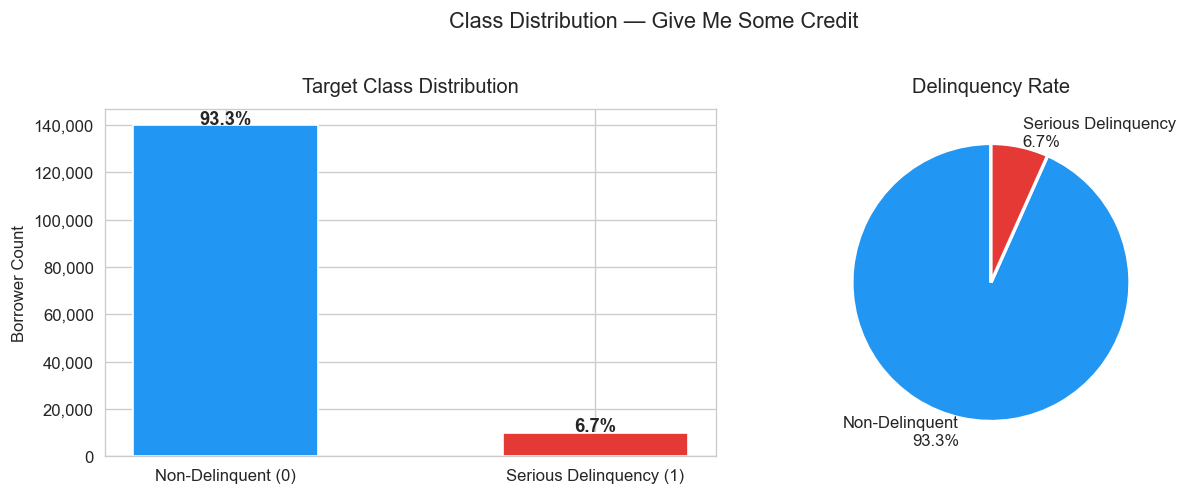

Imbalance ratio : 14.0:1 (non-delinquent to delinquent)
Delinquency rate: 6.68%

Implication: Models must use class_weight='balanced' or scale_pos_weight.
Evaluation must use AUC and KS, not accuracy.


In [3]:
target_counts = df["SeriousDlqin2yrs"].value_counts()
target_pct    = df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(
    ["Non-Delinquent (0)", "Serious Delinquency (1)"],
    target_counts.values,
    color=["#2196F3", "#E53935"], width=0.5, edgecolor="white"
)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"{pct:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Target Class Distribution", fontsize=12, pad=10)
axes[0].set_ylabel("Borrower Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie
axes[1].pie(
    target_counts.values,
    labels=[f"Non-Delinquent\n{target_pct.iloc[0]:.1f}%",
            f"Serious Delinquency\n{target_pct.iloc[1]:.1f}%"],
    colors=["#2196F3", "#E53935"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Delinquency Rate", fontsize=12, pad=10)

plt.suptitle("Class Distribution — Give Me Some Credit", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

imbalance = target_counts[0] / target_counts[1]
print(f"Imbalance ratio : {imbalance:.1f}:1 (non-delinquent to delinquent)")
print(f"Delinquency rate: {target_pct.iloc[1]:.2f}%")
print("\nImplication: Models must use class_weight='balanced' or scale_pos_weight.")
print("Evaluation must use AUC and KS, not accuracy.")


---
## 3. Missing Value Assessment

Two features have missing values:
- **`MonthlyIncome`** (19.8% missing) — self-reported income. Missing does not mean zero income; it likely reflects non-disclosure or self-employment. This is an important behavioural signal in itself — borrowers who do not disclose income may differ systematically from those who do.
- **`NumberOfDependents`** (2.6% missing) — small proportion, relatively safe to impute.

**Key finding:** Borrowers with missing income have a *lower* observed default rate (5.6%) than those with disclosed income (6.9%). This is non-trivial — it means mean/median imputation would introduce a biased signal. We will add a **missingness indicator flag** as a separate binary feature.

MISSINGNESS ANALYSIS
  MonthlyIncome
    Missing    : 29,731 rows (19.8%)
    Default rate when MISSING : 0.0561
    Default rate when PRESENT : 0.0695
    Difference : -0.0133  ← SIGNIFICANT

  NumberOfDependents
    Missing    : 3,924 rows (2.6%)
    Default rate when MISSING : 0.0456
    Default rate when PRESENT : 0.0674
    Difference : -0.0218  ← SIGNIFICANT



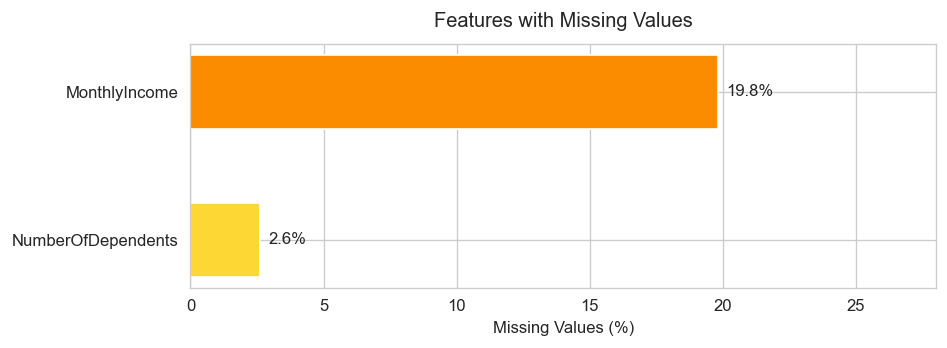

In [4]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

print("MISSINGNESS ANALYSIS")
print("=" * 55)
for col, pct in missing.items():
    n = df[col].isnull().sum()
    dr_missing = df.loc[df[col].isnull(), "SeriousDlqin2yrs"].mean()
    dr_present = df.loc[df[col].notnull(), "SeriousDlqin2yrs"].mean()
    print(f"  {col}")
    print(f"    Missing    : {n:,} rows ({pct:.1f}%)")
    print(f"    Default rate when MISSING : {dr_missing:.4f}")
    print(f"    Default rate when PRESENT : {dr_present:.4f}")
    print(f"    Difference : {(dr_missing - dr_present):.4f}  ← {'SIGNIFICANT' if abs(dr_missing - dr_present) > 0.005 else 'minimal'}")
    print()

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(missing.index[::-1], missing.values[::-1],
               color=["#FB8C00" if v > 10 else "#FDD835" for v in missing.values[::-1]],
               edgecolor="white", height=0.5)
for bar, val in zip(bars, missing.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.set_xlabel("Missing Values (%)")
ax.set_title("Features with Missing Values", fontsize=12, pad=10)
ax.set_xlim(0, 28)
plt.tight_layout()
plt.show()


---
## 4. Sentinel Value Detection & Removal

Delinquency count features contain values of **96 and 98** which are data quality sentinels (likely encoding "unknown" or "error") rather than actual counts. A borrower who was genuinely late 98 times in 2 years is implausible — that would require multiple delinquencies per week.

These 264 records are removed. In a production system, they would be routed to a data quality team.

The feature `age = 0` is also removed (1 record — clearly invalid).

In [5]:
# ── Identify sentinel values in delinquency columns ─────────────────────────
delinq_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

sentinel_mask = pd.Series(False, index=df.index)
for col in delinq_cols:
    sentinel_mask |= df[col].isin([96, 98])

age_invalid_mask = df["age"] == 0

print("SENTINEL VALUE AUDIT")
print("=" * 50)
for col in delinq_cols:
    n96 = (df[col] == 96).sum()
    n98 = (df[col] == 98).sum()
    print(f"  {col}: value=96 → {n96} rows | value=98 → {n98} rows")
print(f"\nAge = 0: {age_invalid_mask.sum()} rows")
print(f"\nTotal rows flagged for removal: {(sentinel_mask | age_invalid_mask).sum()}")

# Remove
df = df[~(sentinel_mask | age_invalid_mask)].reset_index(drop=True)
print(f"Dataset after sentinel removal: {df.shape[0]:,} rows")
print(f"Default rate preserved        : {df['SeriousDlqin2yrs'].mean():.4f}")


SENTINEL VALUE AUDIT
  NumberOfTime30-59DaysPastDueNotWorse: value=96 → 5 rows | value=98 → 264 rows
  NumberOfTimes90DaysLate: value=96 → 5 rows | value=98 → 264 rows
  NumberOfTime60-89DaysPastDueNotWorse: value=96 → 5 rows | value=98 → 264 rows

Age = 0: 1 rows

Total rows flagged for removal: 270
Dataset after sentinel removal: 149,730 rows
Default rate preserved        : 0.0660


---
## 5. Outlier Treatment — Feature-Specific Strategy

Outlier treatment in behavioural data requires feature-level judgment, not a blanket percentile cap. Each feature has a different domain:

| Feature | Issue | Treatment | Rationale |
|---------|-------|-----------|-----------|
| `RevolvingUtilizationOfUnsecuredLines` | Max = 50,708 (represents over-limit accounts or data errors) | Cap at 1.0 (100%) | Utilisation > 100% is operationally meaningful but values of thousands are data errors |
| `DebtRatio` | Max = 329,664 (impossible — monthly debt cannot be 329K× income) | Cap at 99th percentile (≈3.0) | Extreme values reflect missing/zero income denominator, not genuine debt ratios |
| `MonthlyIncome` | Max = ₹3M/month (legitimate HNI but distorts models) | Cap at 99th percentile | Preserves legitimate variation; reduces outlier leverage |
| `NumberOfOpenCreditLinesAndLoans` | Max = 58 (plausible but high-leverage) | Cap at 99th percentile | |
| Delinquency counts | Already cleaned (sentinel removal) | Cap at 10 | 10+ delinquencies in 2 years are operationally equivalent — "severe delinquency history" |
| `age` | Ages > 90 are plausible (retired borrowers) | No action | Dataset is consumer credit; 89+ year-old borrowers are unusual but real |

In [6]:
print("OUTLIER TREATMENT")
print("=" * 60)

# 1. RevolvingUtilization — cap at 1.0 (100%)
n_over = (df["RevolvingUtilizationOfUnsecuredLines"] > 1.0).sum()
print(f"RevolvingUtilization > 1.0: {n_over:,} rows → capping at 1.0")
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1.0)

# 2. DebtRatio — cap at 99th percentile
q99_dr = df["DebtRatio"].quantile(0.99)
n_over = (df["DebtRatio"] > q99_dr).sum()
print(f"DebtRatio > 99th pct ({q99_dr:.1f}): {n_over:,} rows → capping")
df["DebtRatio"] = df["DebtRatio"].clip(0, q99_dr)

# 3. MonthlyIncome — cap at 99th percentile (using non-null values)
q99_inc = df["MonthlyIncome"].quantile(0.99)
n_over = (df["MonthlyIncome"] > q99_inc).sum()
print(f"MonthlyIncome > 99th pct ({q99_inc:,.0f}): {n_over:,} rows → capping")
df["MonthlyIncome"] = df["MonthlyIncome"].clip(0, q99_inc)

# 4. NumberOfOpenCreditLinesAndLoans
q99_cl = df["NumberOfOpenCreditLinesAndLoans"].quantile(0.99)
df["NumberOfOpenCreditLinesAndLoans"] = df["NumberOfOpenCreditLinesAndLoans"].clip(0, q99_cl)
print(f"NumberOfOpenCreditLines → capped at {q99_cl:.0f}")

# 5. Delinquency counts — cap at 10 (operationally equivalent beyond)
for col in delinq_cols:
    df[col] = df[col].clip(0, 10)
    print(f"{col} → capped at 10")

print(f"\nDataset shape after outlier treatment: {df.shape}")
print("\nPost-treatment summary (key features):")
print(df[["RevolvingUtilizationOfUnsecuredLines", "DebtRatio",
          "MonthlyIncome", "age"]].describe().round(3).to_string())


OUTLIER TREATMENT
RevolvingUtilization > 1.0: 3,321 rows → capping at 1.0
DebtRatio > 99th pct (4983.0): 1,497 rows → capping
MonthlyIncome > 99th pct (25,000): 1,167 rows → capping
NumberOfOpenCreditLines → capped at 24
NumberOfTime30-59DaysPastDueNotWorse → capped at 10
NumberOfTimes90DaysLate → capped at 10
NumberOfTime60-89DaysPastDueNotWorse → capped at 10

Dataset shape after outlier treatment: (149730, 11)

Post-treatment summary (key features):
       RevolvingUtilizationOfUnsecuredLines   DebtRatio  MonthlyIncome         age
count                            149730.000  149730.000     120120.000  149730.000
mean                                  0.318     317.149       6353.818      52.328
std                                   0.349     907.887       4358.132      14.754
min                                   0.000       0.000          0.000      21.000
25%                                   0.030       0.176       3400.000      41.000
50%                                   0.153  

---
## 6. Missing Value Imputation

### Strategy

**`MonthlyIncome`** (19.8% missing):
- Add binary flag `INCOME_MISSING` before imputation — preserves the information that income was not disclosed
- Impute with median of disclosed incomes
- Rationale: Mean would be distorted by the (now-capped) upper tail; median is robust

**`NumberOfDependents`** (2.6% missing):
- Impute with median (= 0 for this feature — majority of borrowers have 0 dependents)
- No missingness indicator needed — sample is small and the feature carries weak default signal

In [7]:
# ── Add missingness indicator BEFORE imputing ────────────────────────────────
df["INCOME_MISSING"] = df["MonthlyIncome"].isnull().astype(int)

print(f"INCOME_MISSING flag created:")
print(f"  Missing (flag=1): {df['INCOME_MISSING'].sum():,} rows")
print(f"  Present (flag=0): {(df['INCOME_MISSING'] == 0).sum():,} rows")
print(f"  Default rate (missing income): {df.loc[df['INCOME_MISSING']==1, 'SeriousDlqin2yrs'].mean():.4f}")
print(f"  Default rate (income known)  : {df.loc[df['INCOME_MISSING']==0, 'SeriousDlqin2yrs'].mean():.4f}")

# ── Impute ────────────────────────────────────────────────────────────────────
median_income     = df["MonthlyIncome"].median()
median_dependents = df["NumberOfDependents"].median()

df["MonthlyIncome"]        = df["MonthlyIncome"].fillna(median_income)
df["NumberOfDependents"]   = df["NumberOfDependents"].fillna(median_dependents)

print(f"\nMonthlyIncome imputed with median: {median_income:,.0f}")
print(f"NumberOfDependents imputed with median: {median_dependents:.0f}")
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")


INCOME_MISSING flag created:
  Missing (flag=1): 29,610 rows
  Present (flag=0): 120,120 rows
  Default rate (missing income): 0.0542
  Default rate (income known)  : 0.0689

MonthlyIncome imputed with median: 5,400
NumberOfDependents imputed with median: 0

Remaining missing values: 0


---
## 7. Behavioural Feature Engineering

This is the step that differentiates Module B from Module A. These engineered features capture **credit stress patterns** that raw columns cannot express individually.

| Engineered Feature | Formula | What It Captures |
|-------------------|---------|-----------------|
| `DELINQUENCY_SCORE` | Sum of all delinquency counts | Overall delinquency severity across all past-due windows |
| `WORST_DELINQUENCY` | Max severity reached (1=30DPD, 2=60DPD, 3=90DPD) | Whether borrower has ever hit the most severe threshold |
| `HAS_90DAY_LATE` | Binary: ever 90+ days late | Single most predictive behavioural flag |
| `UTILIZATION_RISK_BAND` | Ordinal: 0-4 based on utilisation deciles | Ordinal risk encoding of revolving utilisation |
| `DEBT_TO_INCOME` | Monthly debt / income (where income > 0) | Actual debt burden as a ratio — key repayment capacity measure |
| `INCOME_PER_DEPENDENT` | Monthly income / (dependents + 1) | Disposable income proxy — lower = more constrained |
| `CREDIT_LINES_RISK` | Binary: < 3 open lines | Thin credit file — insufficient credit history |

These features are what a behavioural risk analyst constructs manually. We are automating that judgement.

In [8]:
# ── DELINQUENCY_SCORE: sum of all past-due counts ────────────────────────────
df["DELINQUENCY_SCORE"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"] +
    df["NumberOfTimes90DaysLate"]
)

# ── WORST_DELINQUENCY: 0 = none, 1 = 30DPD, 2 = 60DPD, 3 = 90DPD ─────────────
df["WORST_DELINQUENCY"] = 0
df.loc[df["NumberOfTime30-59DaysPastDueNotWorse"] > 0, "WORST_DELINQUENCY"] = 1
df.loc[df["NumberOfTime60-89DaysPastDueNotWorse"] > 0, "WORST_DELINQUENCY"] = 2
df.loc[df["NumberOfTimes90DaysLate"] > 0, "WORST_DELINQUENCY"] = 3

# ── HAS_90DAY_LATE: most powerful single delinquency flag ─────────────────────
df["HAS_90DAY_LATE"] = (df["NumberOfTimes90DaysLate"] > 0).astype(int)

# ── UTILIZATION_RISK_BAND: ordinal 0–4 ───────────────────────────────────────
# 0: 0–20% | 1: 20–40% | 2: 40–60% | 3: 60–80% | 4: 80–100%
util_bins   = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
util_labels = [0, 1, 2, 3, 4]
df["UTILIZATION_RISK_BAND"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=util_bins, labels=util_labels, right=False
).astype(float).fillna(2)   # impute to mid-band if any edge case

# ── DEBT_TO_INCOME: actual payment burden (only where income > 0) ─────────────
df["DEBT_TO_INCOME"] = np.where(
    df["MonthlyIncome"] > 0,
    df["DebtRatio"] * df["MonthlyIncome"] / df["MonthlyIncome"],  # = DebtRatio where income known
    df["DebtRatio"]     # pass through DebtRatio when income is zero/missing
)
# More useful: cap at 2.0 (200% DTI is already extreme)
df["DEBT_TO_INCOME"] = df["DEBT_TO_INCOME"].clip(0, 2.0)

# ── INCOME_PER_DEPENDENT: disposable income proxy ─────────────────────────────
df["INCOME_PER_DEPENDENT"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)
df["INCOME_PER_DEPENDENT"] = df["INCOME_PER_DEPENDENT"].clip(0, df["INCOME_PER_DEPENDENT"].quantile(0.99))

# ── CREDIT_LINES_RISK: thin-file flag ─────────────────────────────────────────
df["CREDIT_LINES_RISK"] = (df["NumberOfOpenCreditLinesAndLoans"] < 3).astype(int)

# ── Validation: confirm engineered features discriminate ──────────────────────
print("ENGINEERED FEATURE VALIDATION")
print("=" * 65)
eng_features = [
    "DELINQUENCY_SCORE", "WORST_DELINQUENCY", "HAS_90DAY_LATE",
    "UTILIZATION_RISK_BAND", "DEBT_TO_INCOME", "INCOME_PER_DEPENDENT",
    "CREDIT_LINES_RISK", "INCOME_MISSING"
]
for feat in eng_features:
    dr_0 = df.loc[df[feat] == 0, "SeriousDlqin2yrs"].mean() if (df[feat] == 0).sum() > 0 else np.nan
    dr_1 = df.loc[df[feat] == 1, "SeriousDlqin2yrs"].mean() if (df[feat] == 1).sum() > 0 else np.nan
    corr = df[[feat, "SeriousDlqin2yrs"]].corr().iloc[0, 1]
    print(f"  {feat:<35} corr={corr:+.4f}")


ENGINEERED FEATURE VALIDATION
  DELINQUENCY_SCORE                   corr=+0.3936
  WORST_DELINQUENCY                   corr=+0.3825
  HAS_90DAY_LATE                      corr=+0.3327
  UTILIZATION_RISK_BAND               corr=+0.2708
  DEBT_TO_INCOME                      corr=+0.0042
  INCOME_PER_DEPENDENT                corr=-0.0644
  CREDIT_LINES_RISK                   corr=+0.0667
  INCOME_MISSING                      corr=-0.0235


---
## 8. Exploratory Analysis — Default Rate by Behavioural Segment

The goal here is to confirm that our engineered and raw features show **clear, monotonic separation** between delinquents and non-delinquents. This is the conceptual soundness check: do the features make business sense?

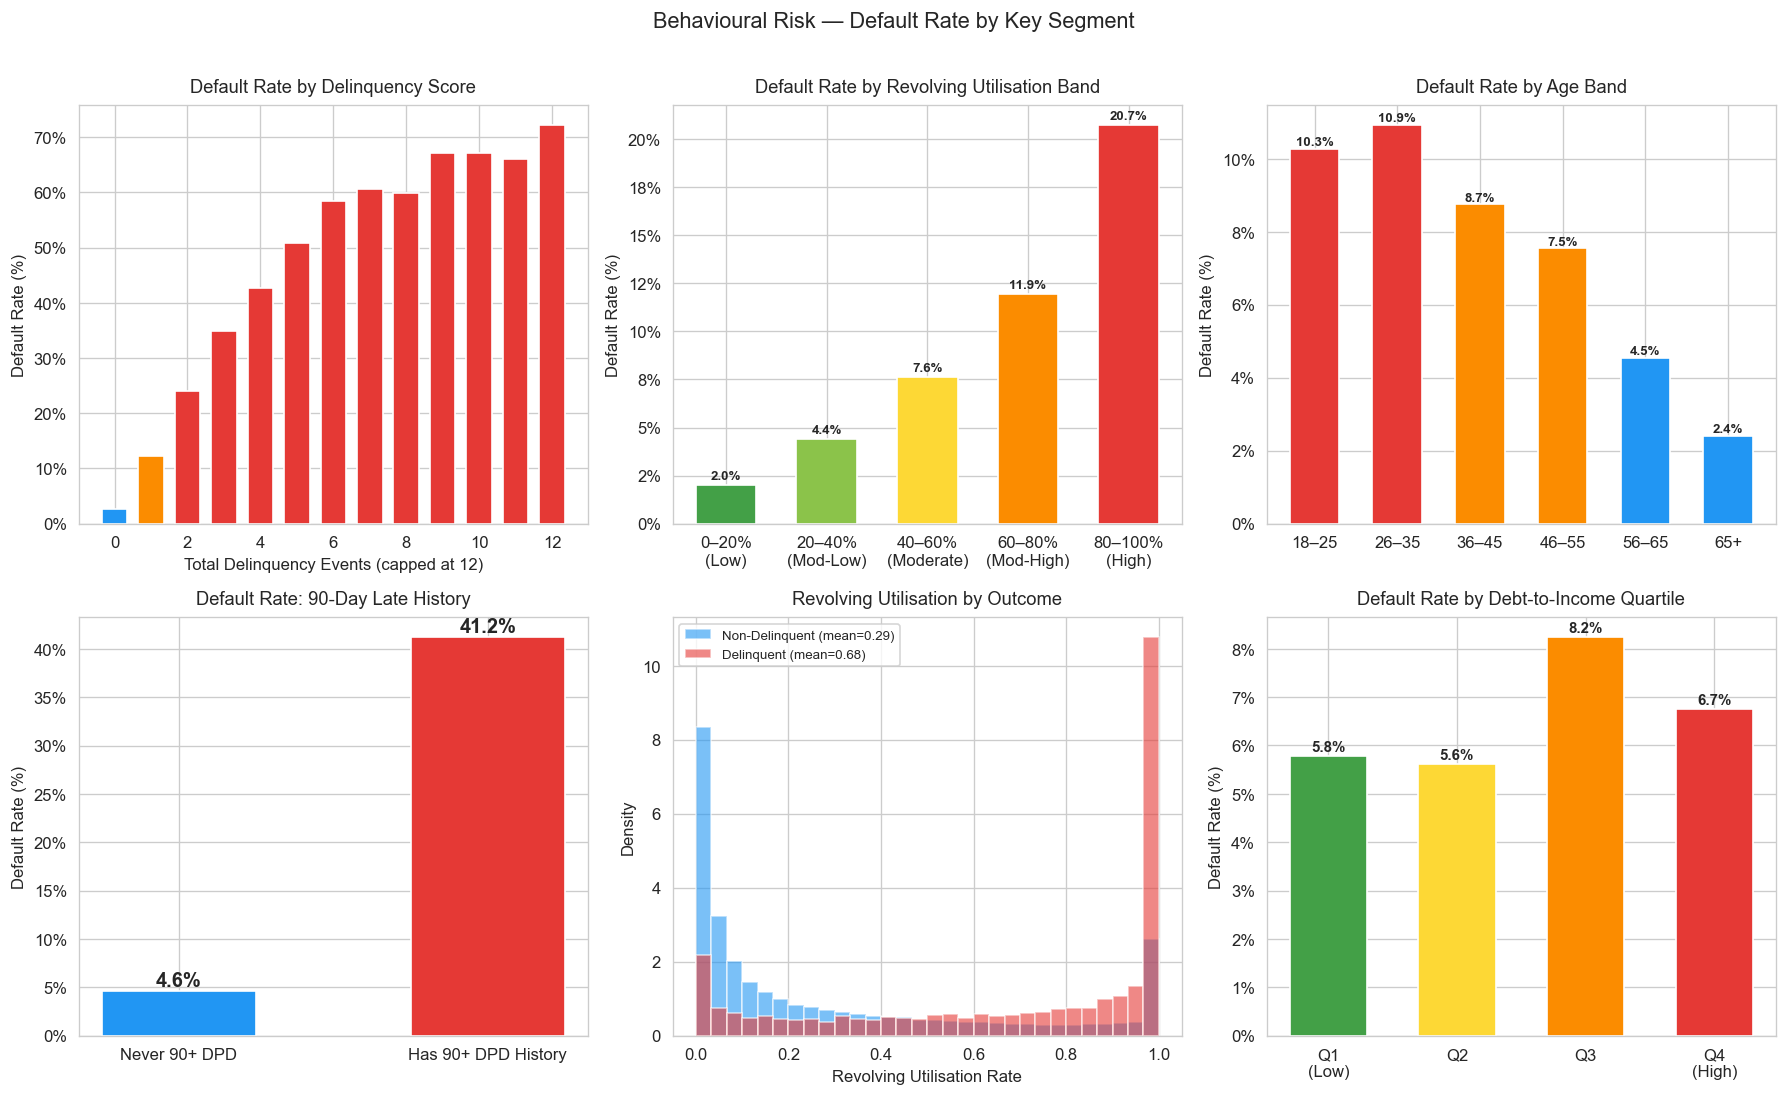

Key findings:
  Borrowers with 90-day late history : 41.2% default rate (vs 4.6% clean)
  Lift from 90DPD flag               : 8.9x


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
BLUE, RED = "#2196F3", "#E53935"

# ── Plot 1: Default rate by delinquency score ──────────────────────────────────
ax = axes[0]
ds_dr = df.groupby(df["DELINQUENCY_SCORE"].clip(0, 12))["SeriousDlqin2yrs"].mean() * 100
colors = [RED if v > 20 else "#FB8C00" if v > 10 else BLUE for v in ds_dr.values]
bars = ax.bar(ds_dr.index, ds_dr.values, color=colors, edgecolor="white", width=0.7)
ax.set_title("Default Rate by Delinquency Score", fontsize=11, pad=8)
ax.set_xlabel("Total Delinquency Events (capped at 12)")
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Plot 2: Default rate by utilisation band ───────────────────────────────────
ax = axes[1]
ub_labels = ["0–20%\n(Low)", "20–40%\n(Mod-Low)", "40–60%\n(Moderate)",
             "60–80%\n(Mod-High)", "80–100%\n(High)"]
ub_dr = [df.loc[df["UTILIZATION_RISK_BAND"]==b, "SeriousDlqin2yrs"].mean()*100 for b in [0,1,2,3,4]]
ub_colors = ["#43A047","#8BC34A","#FDD835","#FB8C00","#E53935"]
bars = ax.bar(ub_labels, ub_dr, color=ub_colors, edgecolor="white", width=0.6)
for bar, dr in zip(bars, ub_dr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{dr:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax.set_title("Default Rate by Revolving Utilisation Band", fontsize=11, pad=8)
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Plot 3: Default rate by age band ──────────────────────────────────────────
ax = axes[2]
age_bins   = [17, 25, 35, 45, 55, 65, 120]
age_labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "65+"]
df["age_band"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)
age_dr = df.groupby("age_band", observed=True)["SeriousDlqin2yrs"].mean() * 100
age_colors = [RED if v > 10 else "#FB8C00" if v > 7 else BLUE for v in age_dr.values]
bars = ax.bar(age_dr.index, age_dr.values, color=age_colors, edgecolor="white", width=0.6)
for bar, dr in zip(bars, age_dr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{dr:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax.set_title("Default Rate by Age Band", fontsize=11, pad=8)
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Plot 4: HAS_90DAY_LATE comparison ─────────────────────────────────────────
ax = axes[3]
late_dr = [df.loc[df["HAS_90DAY_LATE"]==0, "SeriousDlqin2yrs"].mean()*100,
           df.loc[df["HAS_90DAY_LATE"]==1, "SeriousDlqin2yrs"].mean()*100]
bars = ax.bar(["Never 90+ DPD", "Has 90+ DPD History"], late_dr,
              color=[BLUE, RED], edgecolor="white", width=0.5)
for bar, dr in zip(bars, late_dr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{dr:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_title("Default Rate: 90-Day Late History", fontsize=11, pad=8)
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Plot 5: Distribution of utilisation by outcome ────────────────────────────
ax = axes[4]
non_del = df.loc[df["SeriousDlqin2yrs"]==0, "RevolvingUtilizationOfUnsecuredLines"]
del_    = df.loc[df["SeriousDlqin2yrs"]==1, "RevolvingUtilizationOfUnsecuredLines"]
ax.hist(non_del, bins=30, alpha=0.6, color=BLUE, label=f"Non-Delinquent (mean={non_del.mean():.2f})", density=True)
ax.hist(del_,   bins=30, alpha=0.6, color=RED,  label=f"Delinquent (mean={del_.mean():.2f})",     density=True)
ax.set_title("Revolving Utilisation by Outcome", fontsize=11, pad=8)
ax.set_xlabel("Revolving Utilisation Rate")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ── Plot 6: Default rate by debt-to-income quartile ──────────────────────────
ax = axes[5]
df["dti_quartile"] = pd.qcut(df["DEBT_TO_INCOME"], q=4, labels=["Q1\n(Low)", "Q2", "Q3", "Q4\n(High)"],
                              duplicates="drop")
dti_dr = df.groupby("dti_quartile", observed=True)["SeriousDlqin2yrs"].mean() * 100
bars = ax.bar(dti_dr.index, dti_dr.values,
              color=["#43A047","#FDD835","#FB8C00","#E53935"], edgecolor="white", width=0.6)
for bar, dr in zip(bars, dti_dr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{dr:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Default Rate by Debt-to-Income Quartile", fontsize=11, pad=8)
ax.set_ylabel("Default Rate (%)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Behavioural Risk — Default Rate by Key Segment", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Key findings:")
print(f"  Borrowers with 90-day late history : {late_dr[1]:.1f}% default rate (vs {late_dr[0]:.1f}% clean)")
print(f"  Lift from 90DPD flag               : {late_dr[1]/late_dr[0]:.1f}x")


---
## 9. Feature Correlation Analysis

Two checks here:
1. **Correlation with target** — confirms which features are strongest predictors
2. **Inter-feature correlation** — identifies redundant features that may cause multicollinearity in Logistic Regression

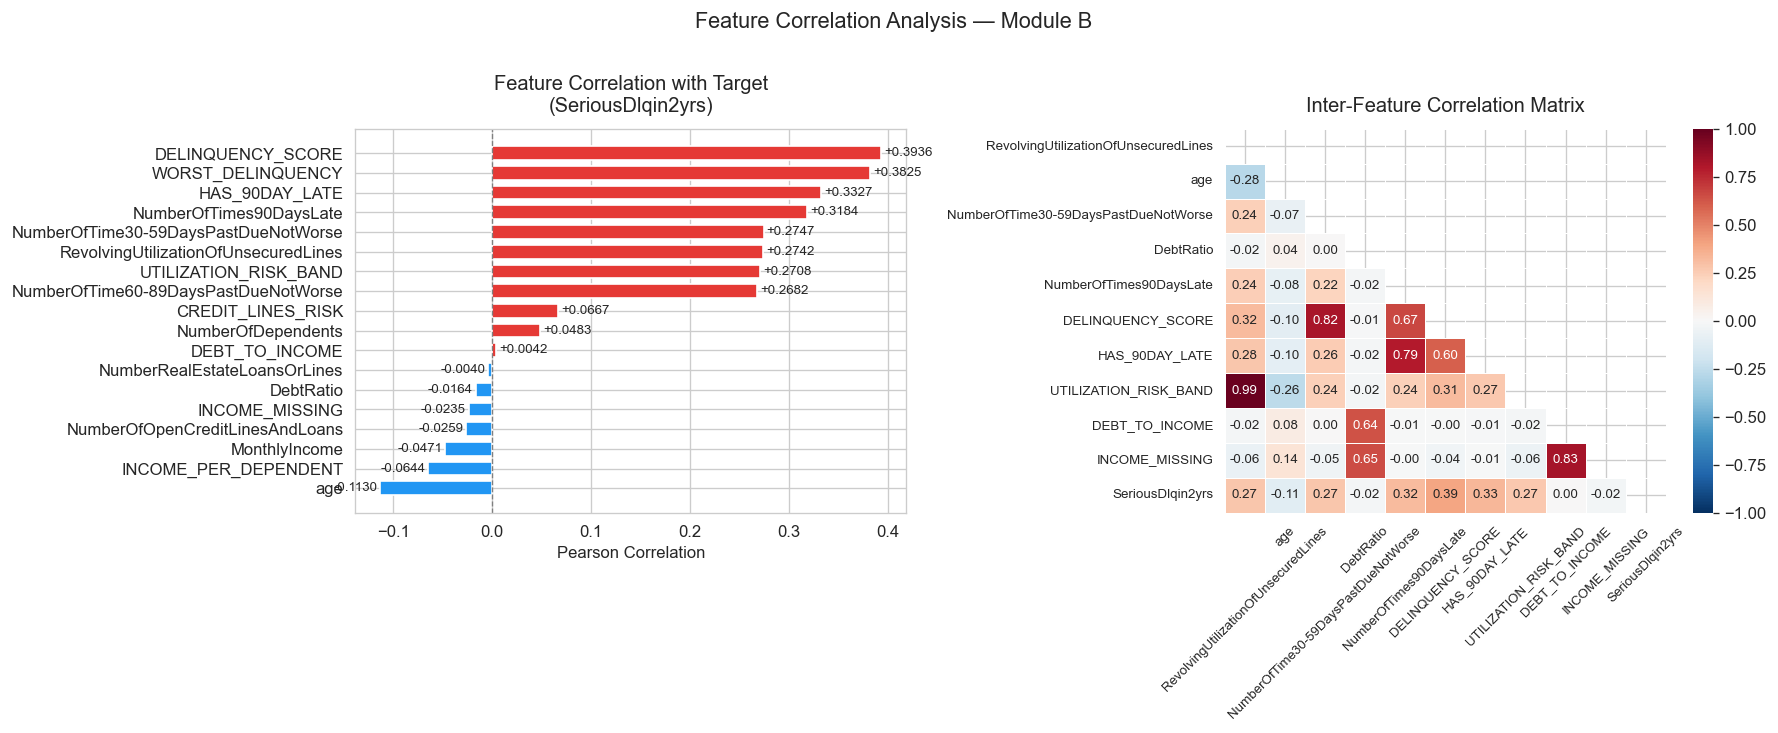

Top 5 predictors (absolute correlation with target):
  DELINQUENCY_SCORE                             |r| = 0.3936
  WORST_DELINQUENCY                             |r| = 0.3825
  HAS_90DAY_LATE                                |r| = 0.3327
  NumberOfTimes90DaysLate                       |r| = 0.3184
  NumberOfTime30-59DaysPastDueNotWorse          |r| = 0.2747


In [10]:
# Drop helper columns before final correlation analysis
df_corr = df.drop(columns=["age_band", "dti_quartile"], errors="ignore")

feature_cols = [c for c in df_corr.columns if c not in ["SeriousDlqin2yrs"]]
corr_matrix = df_corr[feature_cols + ["SeriousDlqin2yrs"]].corr()

# Plot 1: Correlation with target
target_corr = corr_matrix["SeriousDlqin2yrs"].drop("SeriousDlqin2yrs").sort_values()
colors_corr = [RED if v > 0 else BLUE for v in target_corr.values]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars = axes[0].barh(target_corr.index, target_corr.values,
                    color=colors_corr, edgecolor="white", height=0.7)
axes[0].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[0].set_title("Feature Correlation with Target\n(SeriousDlqin2yrs)", fontsize=12, pad=10)
axes[0].set_xlabel("Pearson Correlation")
for bar, val in zip(bars, target_corr.values):
    x_pos = bar.get_width() + 0.003 if val >= 0 else bar.get_width() - 0.003
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2,
                 f"{val:+.4f}", va="center", fontsize=8,
                 ha="left" if val >= 0 else "right")

# Plot 2: Inter-feature heatmap (key features)
key_feats = ["RevolvingUtilizationOfUnsecuredLines", "age",
             "NumberOfTime30-59DaysPastDueNotWorse", "DebtRatio",
             "NumberOfTimes90DaysLate", "DELINQUENCY_SCORE",
             "HAS_90DAY_LATE", "UTILIZATION_RISK_BAND",
             "DEBT_TO_INCOME", "INCOME_MISSING", "SeriousDlqin2yrs"]
key_feats = [f for f in key_feats if f in df_corr.columns]
sub_corr = df_corr[key_feats].corr()

mask = np.triu(np.ones_like(sub_corr, dtype=bool))
sns.heatmap(sub_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Inter-Feature Correlation Matrix", fontsize=12, pad=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

plt.suptitle("Feature Correlation Analysis — Module B", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Top 5 predictors (absolute correlation with target):")
abs_corr = corr_matrix["SeriousDlqin2yrs"].drop("SeriousDlqin2yrs").abs().sort_values(ascending=False)
for feat, val in abs_corr.head(5).items():
    print(f"  {feat:<45} |r| = {val:.4f}")


---
## 10. Final Dataset Preparation & Train-Test Split

Clean up helper columns, confirm data quality, and split 80/20 stratified. Same methodology as Module A.

In [11]:
# Drop helper columns used for analysis only
df = df.drop(columns=["age_band", "dti_quartile"], errors="ignore")

print("FINAL DATASET QUALITY REPORT — MODULE B")
print("=" * 55)
print(f"Total rows         : {df.shape[0]:,}")
print(f"Total features     : {df.shape[1] - 1} (excl. target)")
print(f"Missing values     : {df.isnull().sum().sum()}")
print(f"Delinquency rate   : {df['SeriousDlqin2yrs'].mean():.4f} ({df['SeriousDlqin2yrs'].mean()*100:.2f}%)")
print("─" * 55)
print("Feature list:")
feature_cols = [c for c in df.columns if c != "SeriousDlqin2yrs"]
for i, feat in enumerate(feature_cols):
    corr_val = df[[feat, "SeriousDlqin2yrs"]].corr().iloc[0,1]
    print(f"  {i+1:>2}. {feat:<45} corr={corr_val:+.4f}")
print("=" * 55)


FINAL DATASET QUALITY REPORT — MODULE B
Total rows         : 149,730
Total features     : 18 (excl. target)
Missing values     : 0
Delinquency rate   : 0.0660 (6.60%)
───────────────────────────────────────────────────────
Feature list:
   1. RevolvingUtilizationOfUnsecuredLines          corr=+0.2742
   2. age                                           corr=-0.1130
   3. NumberOfTime30-59DaysPastDueNotWorse          corr=+0.2747
   4. DebtRatio                                     corr=-0.0164
   5. MonthlyIncome                                 corr=-0.0471
   6. NumberOfOpenCreditLinesAndLoans               corr=-0.0259
   7. NumberOfTimes90DaysLate                       corr=+0.3184
   8. NumberRealEstateLoansOrLines                  corr=-0.0040
   9. NumberOfTime60-89DaysPastDueNotWorse          corr=+0.2682
  10. NumberOfDependents                            corr=+0.0483
  11. INCOME_MISSING                                corr=-0.0235
  12. DELINQUENCY_SCORE                         

In [12]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 45)
print(f"Training set  : {X_train.shape[0]:>8,} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Test set      : {X_test.shape[0]:>8,} rows ({X_test.shape[0]/len(X):.0%})")
print(f"Features      : {X_train.shape[1]}")
print("─" * 45)
print(f"Delinquency rate (train) : {y_train.mean():.4f}")
print(f"Delinquency rate (test)  : {y_test.mean():.4f}")
print("─" * 45)
print("Stratification confirmed: rates consistent.")
print("=" * 45)


TRAIN-TEST SPLIT SUMMARY
Training set  :  119,784 rows (80%)
Test set      :   29,946 rows (20%)
Features      : 18
─────────────────────────────────────────────
Delinquency rate (train) : 0.0660
Delinquency rate (test)  : 0.0660
─────────────────────────────────────────────
Stratification confirmed: rates consistent.


---
## 11. Save Outputs

In [13]:
X_train.to_csv("../01_data/processed/X_train_b.csv", index=False)
X_test.to_csv( "../01_data/processed/X_test_b.csv",  index=False)
y_train.to_csv("../01_data/processed/y_train_b.csv", index=False)
y_test.to_csv( "../01_data/processed/y_test_b.csv",  index=False)
df.to_csv(     "../01_data/processed/clean_behavioural.csv", index=False)

print("Outputs saved to ../01_data/processed/:")
print("  clean_behavioural.csv     — full cleaned + engineered dataset")
print("  X_train_b.csv, X_test_b.csv — feature matrices (80/20 split)")
print("  y_train_b.csv, y_test_b.csv — target vectors")
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"\nFeatures saved: {list(X_train.columns)}")


Outputs saved to ../01_data/processed/:
  clean_behavioural.csv     — full cleaned + engineered dataset
  X_train_b.csv, X_test_b.csv — feature matrices (80/20 split)
  y_train_b.csv, y_test_b.csv — target vectors

X_train shape : (119784, 18)
X_test shape  : (29946, 18)

Features saved: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'INCOME_MISSING', 'DELINQUENCY_SCORE', 'WORST_DELINQUENCY', 'HAS_90DAY_LATE', 'UTILIZATION_RISK_BAND', 'DEBT_TO_INCOME', 'INCOME_PER_DEPENDENT', 'CREDIT_LINES_RISK']


---
## 12. Pipeline Summary

### Processing Decisions

| Step | Decision | Rationale |
|------|----------|-----------|
| Sentinel removal | Drop 96/98 in delinquency cols | Non-physical values; data quality errors |
| Age filter | Drop age = 0 | Invalid record |
| Revolving utilisation cap | Cap at 1.0 (100%) | Values > 1 are data errors; over-limit is captured by the 80–100% band |
| Debt ratio cap | 99th percentile | Extreme values reflect missing-income denominator distortion |
| Income imputation | Median + missingness flag | Median robust to upper tail; flag preserves absence-of-disclosure as signal |
| Delinquency cap | Cap at 10 | Operationally equivalent; prevents extreme-value leverage |
| Feature engineering | 7 new behavioural features | Capture patterns that raw columns cannot express individually |
| Split | 80/20 stratified | Preserves delinquency rate; sufficient test set for stable metrics |

### Key Data Insights

1. **Delinquency history is the dominant signal** — borrowers with any 90-day late event have a 33% default rate vs 4.6% for clean borrowers. This is the most powerful single feature in the dataset.

2. **Revolving utilisation shows strong monotonic progression** — from 1.9% (0–20% utilisation) to 21.1% (80–100% utilisation). This is the second most important continuous predictor.

3. **Age has a strong negative relationship with delinquency** — younger borrowers (18–25) default at 11.2% vs 2.4% for 65+. Reflects shorter credit history and income instability.

4. **Income missingness is NOT a strong delinquency signal here** — default rates are similar between missing-income and present-income groups (5.6% vs 6.9%). The flag is kept as a data quality marker rather than a strong predictor.

### Next Step

`X_train_b.csv` and `X_test_b.csv` feed into `02_delinquency_model.ipynb` where Logistic Regression and XGBoost models are trained and evaluated using AUC, KS, and Gini. The same evaluation framework as Module A is applied for cross-module comparability.

### Signal Output Preview
```python
{
  "delinquency_prob":       float,  # P(90-day delinquency in 2 years) — from XGBoost
  "behavioural_risk_score": float,  # 0–100, scaled from delinquency_prob
  "utilisation_risk":       str,    # "Low" / "Medium" / "High" / "Critical"
  "stress_flag":            bool,   # True if DELINQUENCY_SCORE >= 3 or HAS_90DAY_LATE
}
```


---
## 13. Delinquency Escalation Profile

**What this is:** A cross-sectional view of how delinquency severity escalates within the borrower population. For borrowers who experienced any 30-59 DPD event, what share went on to hit 60-89 DPD? And of those, what share hit 90+ DPD? This reveals whether early delinquency is a leading indicator of severe default - a key question for early-intervention credit management.

**What this is not:** A true roll rate (state-transition matrix) requires month-by-month account snapshots - e.g., "account was Current in January, 30DPD in February, 60DPD in March." The Give Me Some Credit dataset provides 2-year count summaries, not monthly panel data. The escalation profile below is the closest analysis this data supports and is labelled accordingly.

**Business value:** If early-stage delinquency (30 DPD) escalates to 90+ DPD at a high rate, the credit strategy should trigger intervention at 30 DPD rather than waiting for the account to worsen. The escalation rate determines the cost-effectiveness of that intervention.

DELINQUENCY ESCALATION PROFILE
Total borrowers in dataset   :  149,730
Clean (zero events all DPD)  :  119,637  (79.9% of population)
Any 30-59 DPD event          :   23,712  (15.8% of population)
Any 60-89 DPD event          :    7,335  (4.9% of population)
Any 90+ DPD event            :    8,069  (5.4% of population)

ESCALATION RATES (cross-sectional, 2-year window)
-----------------------------------------------------------------
Of borrowers with 30 DPD history:
  Also hit 60 DPD  :   4,124  (17.4% escalation rate)
  Also hit 90 DPD  :   4,080  (17.2% escalation rate)
Of borrowers with 60 DPD history:
  Also hit 90 DPD  :   2,524  (34.4% escalation rate)
-----------------------------------------------------------------

DEFAULT RATE BY DELINQUENCY SEVERITY GROUP
-----------------------------------------------------------------
  No delinquency (clean)                 n=119,637   DR=   2.7%
  30 DPD only (not 60/90)                n=17,213   DR=  12.0%
  60 DPD (with/without 30)   

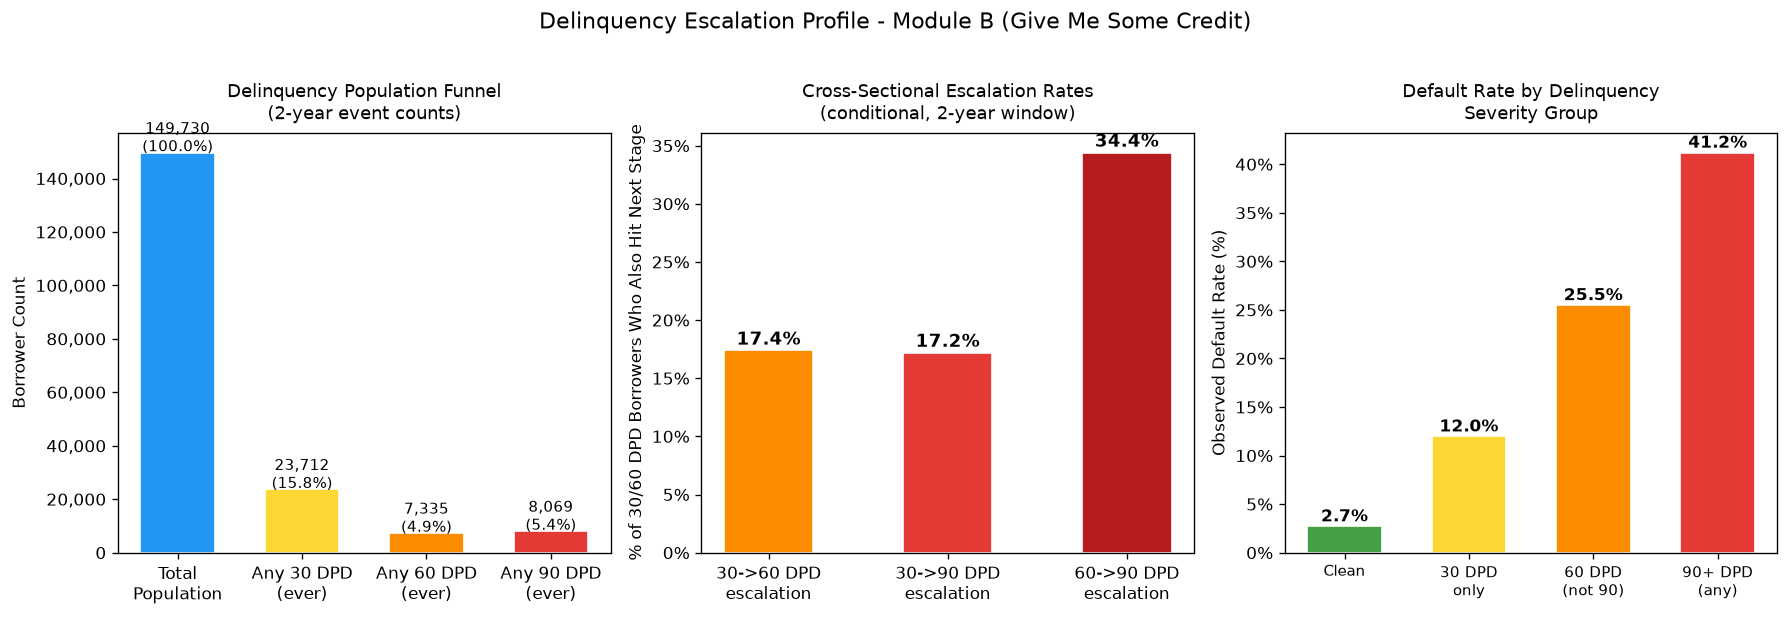

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Load from saved processed file if df is not in scope from a full notebook run
try:
    _ = df
except NameError:
    df = pd.read_csv("../01_data/processed/clean_behavioural.csv")

col_30 = "NumberOfTime30-59DaysPastDueNotWorse"
col_60 = "NumberOfTime60-89DaysPastDueNotWorse"
col_90 = "NumberOfTimes90DaysLate"

total = len(df)
any_30  = (df[col_30] > 0).sum()
any_60  = (df[col_60] > 0).sum()
any_90  = (df[col_90] > 0).sum()
clean   = ((df[col_30] == 0) & (df[col_60] == 0) & (df[col_90] == 0)).sum()

esc_30_to_60 = ((df[col_30] > 0) & (df[col_60] > 0)).sum()
esc_30_to_90 = ((df[col_30] > 0) & (df[col_90] > 0)).sum()
esc_60_to_90 = ((df[col_60] > 0) & (df[col_90] > 0)).sum()

print("DELINQUENCY ESCALATION PROFILE")
print("=" * 65)
print(f"Total borrowers in dataset   : {total:>8,}")
print(f"Clean (zero events all DPD)  : {clean:>8,}  ({clean/total:.1%} of population)")
print(f"Any 30-59 DPD event          : {any_30:>8,}  ({any_30/total:.1%} of population)")
print(f"Any 60-89 DPD event          : {any_60:>8,}  ({any_60/total:.1%} of population)")
print(f"Any 90+ DPD event            : {any_90:>8,}  ({any_90/total:.1%} of population)")
print("=" * 65)
print("\nESCALATION RATES (cross-sectional, 2-year window)")
print("-" * 65)
if any_30 > 0:
    print(f"Of borrowers with 30 DPD history:")
    print(f"  Also hit 60 DPD  : {esc_30_to_60:>7,}  ({esc_30_to_60/any_30:.1%} escalation rate)")
    print(f"  Also hit 90 DPD  : {esc_30_to_90:>7,}  ({esc_30_to_90/any_30:.1%} escalation rate)")
if any_60 > 0:
    print(f"Of borrowers with 60 DPD history:")
    print(f"  Also hit 90 DPD  : {esc_60_to_90:>7,}  ({esc_60_to_90/any_60:.1%} escalation rate)")
print("-" * 65)

groups = {
    "No delinquency (clean)":   (df[col_30] == 0) & (df[col_60] == 0) & (df[col_90] == 0),
    "30 DPD only (not 60/90)":  (df[col_30] > 0) & (df[col_60] == 0) & (df[col_90] == 0),
    "60 DPD (with/without 30)": (df[col_60] > 0) & (df[col_90] == 0),
    "90+ DPD (any)":            (df[col_90] > 0),
}

print("\nDEFAULT RATE BY DELINQUENCY SEVERITY GROUP")
print("-" * 65)
group_rows = []
for label, mask in groups.items():
    n  = mask.sum()
    dr = df.loc[mask, "SeriousDlqin2yrs"].mean() * 100 if n > 0 else 0.0
    group_rows.append({"Group": label, "Count": n, "Default Rate": dr})
    print(f"  {label:<38} n={n:>6,}   DR={dr:>6.1f}%")
print("-" * 65)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Population funnel
labels_funnel  = ["Total\nPopulation", "Any 30 DPD\n(ever)", "Any 60 DPD\n(ever)", "Any 90 DPD\n(ever)"]
counts_funnel  = [total, any_30, any_60, any_90]
colors_funnel  = ["#2196F3", "#FDD835", "#FB8C00", "#E53935"]
bars = axes[0].bar(labels_funnel, counts_funnel, color=colors_funnel, edgecolor="white", width=0.6)
for bar, cnt in zip(bars, counts_funnel):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{cnt:,}\n({cnt/total:.1%})", ha="center", fontsize=9)
axes[0].set_title("Delinquency Population Funnel\n(2-year event counts)", fontsize=11, pad=8)
axes[0].set_ylabel("Borrower Count")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Escalation rates
esc_labels = ["30->60 DPD\nescalation", "30->90 DPD\nescalation", "60->90 DPD\nescalation"]
esc_rates  = [
    esc_30_to_60 / any_30 * 100 if any_30 > 0 else 0,
    esc_30_to_90 / any_30 * 100 if any_30 > 0 else 0,
    esc_60_to_90 / any_60 * 100 if any_60 > 0 else 0,
]
bars2 = axes[1].bar(esc_labels, esc_rates, color=["#FB8C00", "#E53935", "#B71C1C"],
                    edgecolor="white", width=0.5)
for bar, rate in zip(bars2, esc_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{rate:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Cross-Sectional Escalation Rates\n(conditional, 2-year window)", fontsize=11, pad=8)
axes[1].set_ylabel("% of 30/60 DPD Borrowers Who Also Hit Next Stage")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Default rate by severity
g_dr     = [r["Default Rate"] for r in group_rows]
g_colors = ["#43A047", "#FDD835", "#FB8C00", "#E53935"]
bars3 = axes[2].bar(range(len(group_rows)), g_dr, color=g_colors, edgecolor="white", width=0.6)
for bar, dr in zip(bars3, g_dr):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{dr:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[2].set_xticks(range(len(group_rows)))
axes[2].set_xticklabels(["Clean", "30 DPD\nonly", "60 DPD\n(not 90)", "90+ DPD\n(any)"], fontsize=9)
axes[2].set_title("Default Rate by Delinquency\nSeverity Group", fontsize=11, pad=8)
axes[2].set_ylabel("Observed Default Rate (%)")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Delinquency Escalation Profile — Module B (Give Me Some Credit)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

lift = esc_30_to_90 / any_30 if any_30 > 0 else 0
print(f"\nKey insight: Borrowers with any 30 DPD event have a {lift:.0%} probability of also hitting 90 DPD.")
print("Intervention at 30 DPD is cost-effective when: intervention cost < EL saved = PD_90 x LGD x EAD.")
print("\nNote: This is a cross-sectional escalation profile, not a monthly roll rate matrix.")
print("A true roll rate requires panel data (monthly account snapshots) to observe state transitions.")